In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/monkeytype/monkeytyping.csv')
df.head()

,participant_id,date,original_filename,trial_number,reaction_time,correct,correct_position,chosen_position,prompt,sample_name,...,file_path,stimuli_quantity,colored,nut_quantity,juice_quantity,datetime,mean_reaction_time,percent_correct,omission_percent,experiment_duration
0,Jupiter,02.06.2025,02.06.2025 - Jupiter.txt,1,1029,0,2th,3th,NaN,NaN,...,/content/drive/MyDrive/Pavlov/Макаки учатся/Ex...,4.0,NaN,1.0,0.0,02.06.2025 11:59:45,980.0,35.0,4.0,"9 min, 35 sec"
1,Jupiter,02.06.2025,02.06.2025 - Jupiter.txt,2,579,1,2th,2th,NaN,NaN,...,/content/drive/MyDrive/Pavlov/Макаки учатся/Ex...,4.0,NaN,1.0,0.0,02.06.2025 11:59:45,980.0,35.0,4.0,"9 min, 35 sec"
2,Jupiter,02.06.2025,02.06.2025 - Jupiter.txt,3,688,0,3th,4th,NaN,NaN,...,/content/drive/MyDrive/Pavlov/Макаки учатся/Ex...,4.0,NaN,1.0,0.0,02.06.2025 11:59:45,980.0,35.0,4.0,"9 min, 35 sec"
3,Jupiter,02.06.2025,02.06.2025 - Jupiter.txt,4,578,0,4th,2th,NaN,NaN,...,/content/drive/MyDrive/Pavlov/Макаки учатся/Ex...,4.0,NaN,1.0,0.0,02.06.2025 11:59:45,980.0,35.0,4.0,"9 min, 35 sec"
4,Jupiter,02.06.2025,02.06.2025 - Jupiter.txt,5,848,1,4th,4th,NaN,NaN,...,/content/drive/MyDrive/Pavlov/Макаки учатся/Ex...,4.0,NaN,1.0,0.0,02.06.2025 11:59:45,980.0,35.0,4.0,"9 min, 35 sec"


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6159 entries, 0 to 6158
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   participant_id             6159 non-null   object 
 1   date                       6159 non-null   object 
 2   original_filename          6159 non-null   object 
 3   trial_number               6159 non-null   int64  
 4   reaction_time              6159 non-null   object 
 5   correct                    6159 non-null   int64  
 6   correct_position           6159 non-null   object 
 7   chosen_position            6159 non-null   object 
 8   prompt                     0 non-null      float64
 9   sample_name                0 non-null      float64
 10  file_1_name                6159 non-null   object 
 11  file_2_name                6159 non-null   object 
 12  file_3_name                6139 non-null   object 
 13  file_4_name                6139 non-null   objec

In [5]:
df['participant_id_normalized'].unique()

array(['Jupiter', 'Feliks', 'Yunt'], dtype=object)

In [ ]:
df_colors = df[df['colored'].notna()].copy(deep=True)

df_colors.info()

<class 'pandas.core.frame.DataFrame'>
Index: 800 entries, 3709 to 4508
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   participant_id             800 non-null    object 
 1   date                       800 non-null    object 
 2   original_filename          800 non-null    object 
 3   trial_number               800 non-null    int64  
 4   reaction_time              800 non-null    object 
 5   correct                    800 non-null    int64  
 6   correct_position           800 non-null    object 
 7   chosen_position            800 non-null    object 
 8   prompt                     0 non-null      float64
 9   sample_name                0 non-null      float64
 10  file_1_name                800 non-null    object 
 11  file_2_name                800 non-null    object 
 12  file_3_name                800 non-null    object 
 13  file_4_name                800 non-null    object 


In [6]:
df_symbols = df[df['colored'].isna()].copy(deep=True)
df_symbols = df_symbols[df_symbols['file_3_name'].notna()].copy(deep=True)
df_symbols = df_symbols[df_symbols['chosen_position']!='No decision'].copy(deep=True)
df_symbols.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4675 entries, 0 to 6158
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   participant_id             4675 non-null   object 
 1   date                       4675 non-null   object 
 2   original_filename          4675 non-null   object 
 3   trial_number               4675 non-null   int64  
 4   reaction_time              4675 non-null   object 
 5   correct                    4675 non-null   int64  
 6   correct_position           4675 non-null   object 
 7   chosen_position            4675 non-null   object 
 8   prompt                     0 non-null      float64
 9   sample_name                0 non-null      float64
 10  file_1_name                4675 non-null   object 
 11  file_2_name                4675 non-null   object 
 12  file_3_name                4675 non-null   object 
 13  file_4_name                4675 non-null   object 
 1

In [7]:
print(df_symbols[df_symbols['correct_position']==df_symbols['chosen_position']]['correct'].value_counts())

correct
1    1263
Name: count, dtype: int64


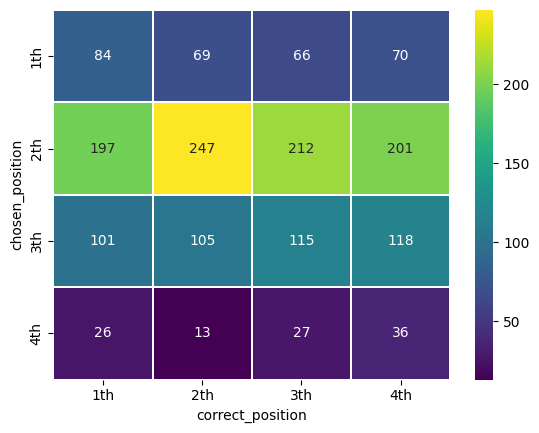

In [8]:
df_Jupiter = df_symbols[df_symbols['participant_id']=='Jupiter'].copy(deep=True)
heatmap_positions_Jupiter = pd.crosstab(df_Jupiter['chosen_position'], df_Jupiter['correct_position']) #normalize = 'all'
ax = sns.heatmap(heatmap_positions_Jupiter, linewidth=0.2, cmap='viridis', annot=True, fmt = ".0f")
plt.show()

[np.float64(0.2738), np.float64(0.5691), np.float64(0.0847), np.float64(0.2059)]


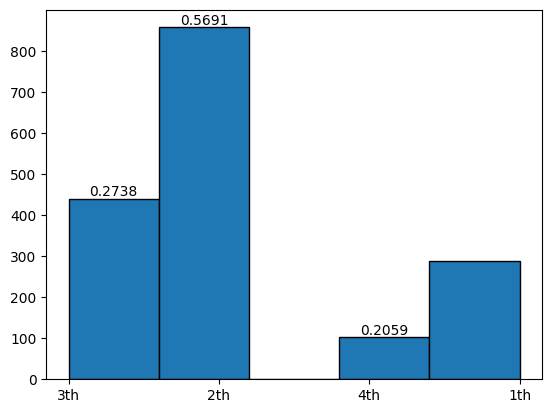

In [9]:
positions = ['3th', '2th', '4th', '1th']
rel_accuracy = []
for pos in positions:
  rel_accuracy.append(np.round(heatmap_positions_Jupiter[pos][pos] / (heatmap_positions_Jupiter[pos].sum()), 4))
print(rel_accuracy)
counts, bins, patches = plt.hist(df_Jupiter['chosen_position'], bins=5, edgecolor='black')
for count, bin_edge, ra in zip(counts, bins[:-1], rel_accuracy): # bins[:-1] to match counts with the start of each bin
    if count > 0: # Only label bars with a count greater than zero
        plt.text(bin_edge + (bins[1] - bins[0]) / 2, # X-coordinate: center of the bar
                  count,                               # Y-coordinate: top of the bar
                  str(ra),                     # The label text (count as integer)
                  ha='center',                         # Horizontal alignment: center
                  va='bottom')

correct_position
2th    561
1th    547
4th    546
3th    503
Name: count, dtype: int64


<Axes: >

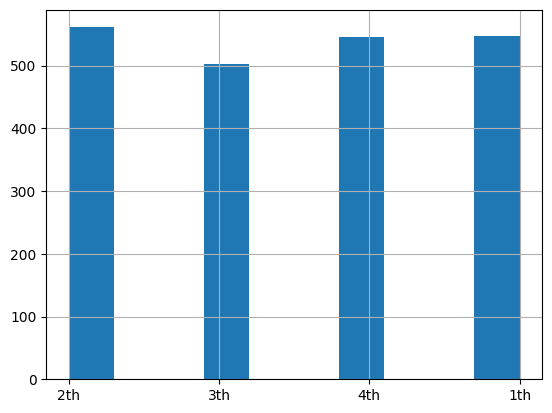

In [ ]:
print(df_symbols[df_symbols['participant_id']=='Jupiter']['correct_position'].value_counts())
df_symbols[df_symbols['participant_id']=='Jupiter']['correct_position'].hist()

In [ ]:
#pd.set_option('display.max_rows', None)
df_Jupiter['trial_number'].value_counts()

,count
trial_number,
1,43
2,43
3,43
4,43
5,43
...,...
57,1
58,1
59,1


In [ ]:
df_Jupiter.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2157 entries, 0 to 2156
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   participant_id             2157 non-null   object 
 1   date                       2157 non-null   object 
 2   original_filename          2157 non-null   object 
 3   trial_number               2157 non-null   int64  
 4   reaction_time              2157 non-null   object 
 5   correct                    2157 non-null   int64  
 6   correct_position           2157 non-null   object 
 7   chosen_position            2157 non-null   object 
 8   prompt                     0 non-null      float64
 9   sample_name                0 non-null      float64
 10  file_1_name                2157 non-null   object 
 11  file_2_name                2157 non-null   object 
 12  file_3_name                2157 non-null   object 
 13  file_4_name                2157 non-null   object 
 1

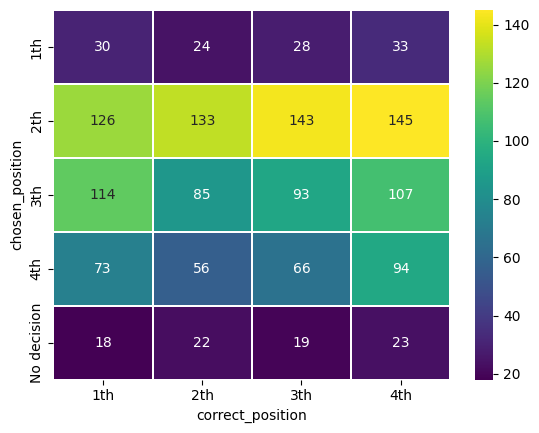

In [ ]:
df_Feliks = df_symbols[df_symbols['participant_id']=='Feliks'].copy(deep=True)
heatmap_positions_Feliks = pd.crosstab(df_Feliks['chosen_position'], df_Feliks['correct_position']) #normalize = 'all'
ax = sns.heatmap(heatmap_positions_Feliks, linewidth=0.2, cmap='viridis', annot=True, fmt = ".0f")
plt.show()

[np.float64(0.2665), np.float64(0.0831), np.float64(0.4156), np.float64(0.2338)]


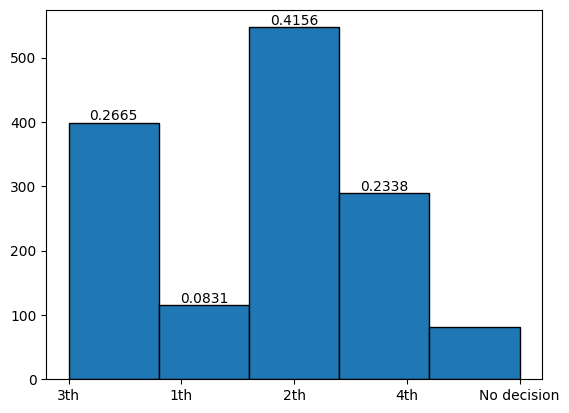

In [ ]:
positions = ['3th', '1th', '2th', '4th']
rel_accuracy = []
for pos in positions:
  rel_accuracy.append(np.round(heatmap_positions_Feliks[pos][pos] / (heatmap_positions_Feliks[pos].sum()), 4))
print(rel_accuracy)
counts, bins, patches = plt.hist(df_Feliks['chosen_position'], bins=5, edgecolor='black')
for count, bin_edge, ra in zip(counts, bins[:-1], rel_accuracy): # bins[:-1] to match counts with the start of each bin
    if count > 0: # Only label bars with a count greater than zero
        plt.text(bin_edge + (bins[1] - bins[0]) / 2, # X-coordinate: center of the bar
                  count,                               # Y-coordinate: top of the bar
                  str(ra),                     # The label text (count as integer)
                  ha='center',                         # Horizontal alignment: center
                  va='bottom')

correct_position
4th    402
1th    361
3th    349
2th    320
Name: count, dtype: int64


<Axes: >

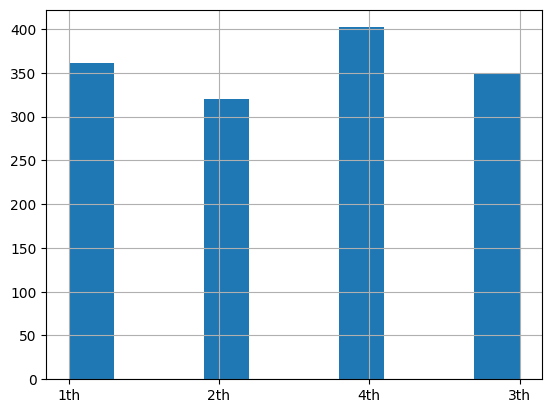

In [ ]:
print(df_symbols[df_symbols['participant_id']=='Feliks']['correct_position'].value_counts())
df_symbols[df_symbols['participant_id']=='Feliks']['correct_position'].hist()

In [ ]:
df_Feliks['trial_number'].value_counts()

,count
trial_number,
1,29
2,29
3,29
4,29
5,29
6,29
7,29
8,29
9,29


In [ ]:
df_Feliks.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1432 entries, 2157 to 3608
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   participant_id             1432 non-null   object 
 1   date                       1432 non-null   object 
 2   original_filename          1432 non-null   object 
 3   trial_number               1432 non-null   int64  
 4   reaction_time              1432 non-null   object 
 5   correct                    1432 non-null   int64  
 6   correct_position           1432 non-null   object 
 7   chosen_position            1432 non-null   object 
 8   prompt                     0 non-null      float64
 9   sample_name                0 non-null      float64
 10  file_1_name                1432 non-null   object 
 11  file_2_name                1432 non-null   object 
 12  file_3_name                1432 non-null   object 
 13  file_4_name                1432 non-null   object 

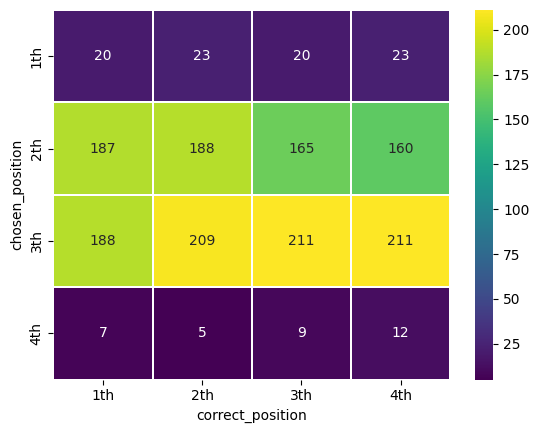

In [10]:
df_Yunt = df_symbols[df_symbols['participant_id']=='Yunt'].copy(deep=True)
heatmap_positions_Yunt = pd.crosstab(df_Yunt['chosen_position'], df_Yunt['correct_position']) #normalize = 'all'
ax = sns.heatmap(heatmap_positions_Yunt, linewidth=0.2, cmap='viridis', annot=True, fmt = ".0f")
plt.show()

[0.0, np.float64(0.493), np.float64(0.4187), np.float64(0.0281), np.float64(0.0448)]


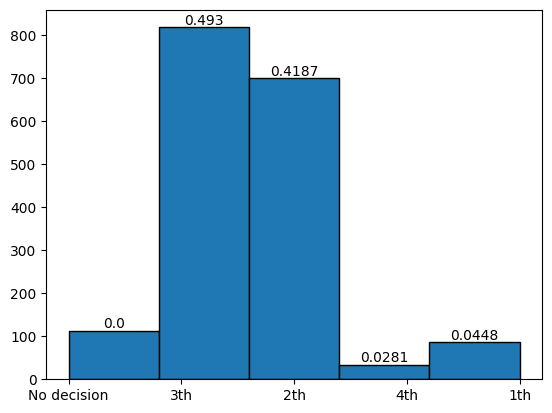

In [ ]:
positions = ['3th', '2th', '4th', '1th']
rel_accuracy = [0.0]
for pos in positions:
  rel_accuracy.append(np.round(heatmap_positions_Yunt[pos][pos] / (heatmap_positions_Yunt[pos].sum()), 4))
print(rel_accuracy)
counts, bins, patches = plt.hist(df_Yunt['chosen_position'], bins=5, edgecolor='black')
for count, bin_edge, ra in zip(counts, bins[:-1], rel_accuracy): # bins[:-1] to match counts with the start of each bin
    if count > 0: # Only label bars with a count greater than zero
        plt.text(bin_edge + (bins[1] - bins[0]) / 2, # X-coordinate: center of the bar
                  count,                               # Y-coordinate: top of the bar
                  str(ra),                     # The label text (count as integer)
                  ha='center',                         # Horizontal alignment: center
                  va='bottom')

correct_position
2th    449
1th    446
3th    428
4th    427
Name: count, dtype: int64


<Axes: >

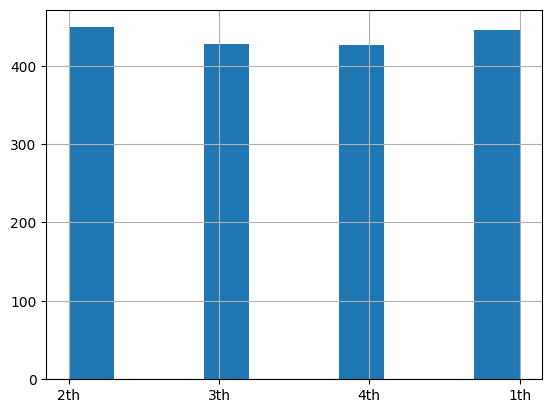

In [ ]:
print(df_symbols[df_symbols['participant_id']=='Yunt']['correct_position'].value_counts())
df_symbols[df_symbols['participant_id']=='Yunt']['correct_position'].hist()

In [ ]:
df_Yunt.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1750 entries, 3609 to 6158
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   participant_id             1750 non-null   object 
 1   date                       1750 non-null   object 
 2   original_filename          1750 non-null   object 
 3   trial_number               1750 non-null   int64  
 4   reaction_time              1750 non-null   object 
 5   correct                    1750 non-null   int64  
 6   correct_position           1750 non-null   object 
 7   chosen_position            1750 non-null   object 
 8   prompt                     0 non-null      float64
 9   sample_name                0 non-null      float64
 10  file_1_name                1750 non-null   object 
 11  file_2_name                1750 non-null   object 
 12  file_3_name                1750 non-null   object 
 13  file_4_name                1750 non-null   object 

In [ ]:
df_Yunt['trial_number'].value_counts()

,count
trial_number,
1,34
2,34
3,34
4,34
5,34
...,...
96,1
97,1
98,1


In [ ]:
#для чтения сессий из всего датафрейма
#idx = df.index[df['val'] == 1]  # индексы, где значение = 1
#segments = []

#for i in range(len(idx) - 1):
#    start = idx[i]
#    end = idx[i+1]            # не включаем следующую 1
#    segment = df.loc[start:end-1]
#    segments.append(segment)

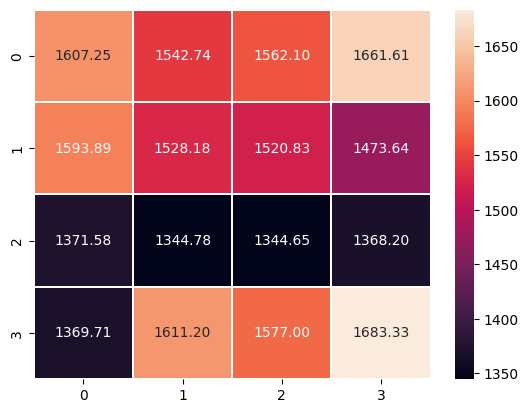

In [ ]:
indexes = df_symbols['correct_position'].unique()
indexes.sort()

matrix_mean_time = np.zeros((4, 4))

for i in range(indexes.shape[0]):
  df_temp_i = df_Yunt[df_Yunt['chosen_position']==indexes[i]]
  for j in range(indexes.shape[0]):
    df_temp_j = df_temp_i[df_temp_i['correct_position']==indexes[j]]
    numberic_df_temp_j =pd.to_numeric(df_temp_j[df_temp_j['reaction_time']!="No answer"]['reaction_time'], errors='coerce')
    matrix_mean_time[i][j] = numberic_df_temp_j.mean()
#print(matrix_mean_time)
ax = sns.heatmap(matrix_mean_time, linewidth=0.2, annot=True, fmt = ".2f", )
plt.show()